# Attr-Only Elbow Like-Game Clustering

This notebook clusters games using `game_attr` attributes only. It intentionally excludes cabinet-name features and performance-derived features from the clustering matrix.

The relationship map is used only to keep accepted attr-to-historical-game links and to produce the final like-game mapping table. Low-confidence review/fuzzy/no-match relationship rows are dropped before matching.

Cluster count is selected with an elbow view. The default chosen cluster count is 8 because that looked more useful for review than maximizing silhouette.


In [1]:
from pathlib import Path
import ast
import json
import math
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, fcluster, linkage
from scipy.spatial.distance import pdist, squareform

try:
    from IPython.display import display
except Exception:
    display = print

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 140)
pd.set_option("display.width", 220)

ROOT = Path.cwd()
if not (ROOT / "Data").exists() and (ROOT.parent / "Data").exists():
    ROOT = ROOT.parent

ATTR_PATH = ROOT / "Data" / "processed" / "game_attr_cleaned.csv"
ATTR_RAW_PATH = ROOT / "Data" / "raw sample" / "game_attr (2).csv"
REL_MAP_PATH = ROOT / "Data" / "processed" / "attr_clean_to_perf_best_match_mapping_all_best_candidates.csv"

OUTPUT_DIR = ROOT / "Data" / "processed" / "reports" / "attr_only_elbow_clustering"
CLUSTER_CHART_DIR = OUTPUT_DIR / "cluster_feature_charts"
HOLDOUT_CHART_DIR = OUTPUT_DIR / "holdout_feature_charts"
for path in [OUTPUT_DIR, CLUSTER_CHART_DIR, HOLDOUT_CHART_DIR]:
    path.mkdir(parents=True, exist_ok=True)

PROFILES_OUTPUT_PATH = ROOT / "Data" / "processed" / "attr_only_elbow_profiles.csv"
FEATURE_MATRIX_OUTPUT_PATH = ROOT / "Data" / "processed" / "attr_only_elbow_features.csv"
MAPPING_OUTPUT_PATH = ROOT / "Data" / "processed" / "attr_only_elbow_like_game_mapping.csv"
GROUPED_MAPPING_OUTPUT_PATH = ROOT / "Data" / "processed" / "attr_only_elbow_like_game_mapping_grouped.csv"
CLUSTER_SUMMARY_OUTPUT_PATH = ROOT / "Data" / "processed" / "attr_only_elbow_cluster_summary.csv"
ELBOW_OUTPUT_PATH = OUTPUT_DIR / "elbow_scores.csv"
CHART_INDEX_OUTPUT_PATH = OUTPUT_DIR / "chart_index.csv"
MANIFEST_OUTPUT_PATH = OUTPUT_DIR / "manifest.json"

print(f"Project root: {ROOT}")
print(f"Attr input: {ATTR_PATH}")
print(f"Relationship map: {REL_MAP_PATH}")

Project root: c:\EveriTools\Workspace\Code\DemandForeCast
Attr input: c:\EveriTools\Workspace\Code\DemandForeCast\Data\processed\game_attr_cleaned.csv
Relationship map: c:\EveriTools\Workspace\Code\DemandForeCast\Data\processed\attr_clean_to_perf_best_match_mapping_all_best_candidates.csv


In [2]:
HOLDOUT_FRACTION = 0.10
MIN_HOLDOUT_ROWS = 1
MAX_LIKE_GAMES_PER_TARGET = None  # None keeps every historical attr game inside the smallest qualifying dendrogram cluster.

LINKAGE_METHOD = "complete"
DISTANCE_METRIC = "cosine"
ELBOW_MIN_CLUSTERS = 2
ELBOW_MAX_CLUSTERS = 16
ELBOW_SELECTED_N_CLUSTERS = 8
MAX_DENDROGRAM_LEAVES = 90
MAX_TEXT_TOKENS = 140
TOP_CLUSTER_FEATURES = 14
TOP_HOLDOUT_FEATURES = 16

EXCLUDED_MATCH_METHODS = {
    "possible_review_fuzzy",
    "weak_review_only",
    "no_match",
}

ATTR_FEATURE_MULTIPLIER = 2.0
TEXT_TOKEN_WEIGHT = 0.70
PROFILE_BIAS_WEIGHT = 0.01

In [3]:
attr = pd.read_csv(ATTR_PATH, low_memory=False)
rel = pd.read_csv(REL_MAP_PATH, low_memory=False)

raw_extra_columns = [
    "theme_sk",
    "family_nk",
    "brand_nk",
    "brand_name",
    "cert_family_ref",
    "business_segment",
    "lines",
    "ways",
    "gaming_channel_cd",
    "volatility_cd",
    "progressive_tiers",
    "na_release_date",
    "lac_release_date",
    "emea_release_date",
    "apac_release_date",
]
if ATTR_RAW_PATH.exists():
    attr_raw = pd.read_csv(ATTR_RAW_PATH, usecols=lambda column: column in raw_extra_columns, low_memory=False)
    attr_raw = attr_raw.drop_duplicates(subset=["theme_sk"])
    extra_cols = [column for column in attr_raw.columns if column != "theme_sk"]
    attr = attr.merge(attr_raw[["theme_sk", *extra_cols]], on="theme_sk", how="left")

print(f"Attr rows: {len(attr):,}; columns after raw extras: {len(attr.columns):,}")
print(f"Relationship-map rows before filter: {len(rel):,}")
display(attr.head(3))
display(rel.head(3))

Attr rows: 4,394; columns after raw extras: 49
Relationship-map rows before filter: 5,538


,theme_sk,theme_nk,source_system_cd,source_company_cd,theme_name,theme_name_friendly,family_name,math_model_family,product_family,game_type,game_matrix,studio_sk,product_segment,product_line,rtp_default,max_bet,min_bet,progressive_type_sk,is_wap,is_poker,is_mlp,is_multi_game,is_tournament_capable,is_multi_denom,audit_etl_id,audit_created_by,audit_created_date,audit_modified_by,audit_modified_date,audit_is_deleted,game_matrix_bingo,game_matrix_hhr_exacta,game_matrix_lottery,game_matrix_prize_first_slot,game_matrix_reels_first_slot,family_nk,brand_nk,brand_name,cert_family_ref,business_segment,lines,ways,gaming_channel_cd,volatility_cd,progressive_tiers,na_release_date,lac_release_date,emea_release_date,apac_release_date
0,1,0000,ATLASSIAN,EVERI,InitialRelease_Template_GameTitle,InitialRelease_Template_GameTitle,NaN,NaN,Standard Video,Not Banked,NaN,-1,Dropped,Standard Video,NaN,NaN,NaN,-1,False,False,False,False,False,False,1032418605116552,1e787607-5ff7-4bfc-9ebc-694c2e5869f9,2026-06-23T17:07:49.405Z,1e787607-5ff7-4bfc-9ebc-694c2e5869f9,2026-06-23T17:07:49.405Z,False,False,False,False,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,10000,ATLASSIAN,EVERI,Tourney Now Star Struck,Tourney Now Star Struck,NaN,['Reels First Slot'],TE ORT,Not Banked,['Reels First Slot'],-1,Approved for TE Drive,TE ORT,NaN,1.0,1.0,-1,False,False,False,False,False,True,1032418605116552,1e787607-5ff7-4bfc-9ebc-694c2e5869f9,2026-06-23T17:07:49.405Z,1e787607-5ff7-4bfc-9ebc-694c2e5869f9,2026-06-23T17:07:49.405Z,False,False,False,False,False,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,10003,ATLASSIAN,EVERI,Little Shop of Horrors - Flex HHR,Little Shop of Horrors - Flex HHR,NaN,['HHR [Exacta]'],Standard Video,Not Banked,['HHR [Exacta]'],-1,Released,Standard Video,NaN,375.0,75.0,-1,False,False,False,False,False,True,1032418605116552,1e787607-5ff7-4bfc-9ebc-694c2e5869f9,2026-06-23T17:07:49.405Z,1e787607-5ff7-4bfc-9ebc-694c2e5869f9,2026-06-23T17:07:49.405Z,False,False,True,False,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,theme_name_friendly,perf_game_name,game_release_date,premium_core,parent_own_status,game_classification,match_method,match_score,recommended_confidence,join_recommendation,metadata_status,attr_row,attr_clean_key,perf_clean_key,candidate_count_same_key,candidate_release_dates,candidate_premium_core_values,candidate_names_sample,unique_release_date_for_key,unique_premium_core_for_key
0,tourney now star struck,5 star,2017-11-01,core,core,class 3,weak_review_only,85.5,weak_do_not_use_without_review,do_not_use_weak_match,ok,4,tourney now star struck,5 star,1,2017-11-01,core,5 star,yes,yes
1,little shop of horrors - flex hhr,little shop of horrors,2017-10-01,core,core,class 3,aggressive_clean_exact,100.0,safe_if_suffix_cleanup_accepted,use_high_confidence,ok,5,little shop of horrors,little shop of horrors,1,2017-10-01,core,little shop of horrors,yes,yes
2,great tiger gold,great tiger gold,2024-03-01,core,core,class 3,raw_exact,100.0,safe_exact,use_high_confidence,ok,6,great tiger gold,great tiger gold,1,2024-03-01,core,great tiger gold,yes,yes


In [4]:
def norm_text(value):
    if pd.isna(value):
        return pd.NA
    text = str(value).strip().lower()
    text = re.sub(r"\s+", " ", text)
    return text if text else pd.NA


def clean_category(value):
    text = norm_text(value)
    if pd.isna(text):
        return "__missing__"
    text = re.sub(r"[\[\]'\\\"]", "", str(text))
    text = re.sub(r"\s+", " ", text).strip()
    return text if text else "__missing__"


def numeric_series(series):
    cleaned = (
        series.astype("string")
        .str.replace(",", "", regex=False)
        .str.replace("$", "", regex=False)
        .str.replace("%", "", regex=False)
        .str.strip()
    )
    return pd.to_numeric(cleaned, errors="coerce")


def bool_series(series):
    truthy = {"true", "1", "y", "yes", "t"}
    falsy = {"false", "0", "n", "no", "f"}

    def convert(value):
        if pd.isna(value):
            return np.nan
        if isinstance(value, bool):
            return 1.0 if value else 0.0
        text = str(value).strip().lower()
        if text in truthy:
            return 1.0
        if text in falsy:
            return 0.0
        number = pd.to_numeric(text, errors="coerce")
        if pd.isna(number):
            return np.nan
        return 1.0 if float(number) != 0 else 0.0

    return series.map(convert).astype(float)


def list_unique(series, limit=8):
    values = []
    seen = set()
    for value in series.dropna().astype(str):
        cleaned = value.strip()
        key = cleaned.lower()
        if not cleaned or key in seen:
            continue
        values.append(cleaned)
        seen.add(key)
        if len(values) >= limit:
            break
    return " | ".join(values)


def parse_listish(value):
    if pd.isna(value):
        return []
    if isinstance(value, (list, tuple, set)):
        return [str(item).strip() for item in value if str(item).strip()]
    text = str(value).strip()
    if not text:
        return []
    try:
        parsed = ast.literal_eval(text)
        if isinstance(parsed, (list, tuple, set)):
            return [str(item).strip() for item in parsed if str(item).strip()]
    except Exception:
        pass
    return [piece.strip() for piece in re.split(r"[,;|/]+", text) if piece.strip()]


def months_between(later, earlier):
    if pd.isna(later) or pd.isna(earlier):
        return np.nan
    return (later.year - earlier.year) * 12 + (later.month - earlier.month)


def release_age_bucket(months):
    if pd.isna(months):
        return "unknown_age"
    if months < 6:
        return "0_5_months"
    if months < 12:
        return "6_11_months"
    if months < 24:
        return "12_23_months"
    if months < 48:
        return "24_47_months"
    if months < 84:
        return "48_83_months"
    return "84_plus_months"


def robust_scale_01(series):
    values = numeric_series(series).astype(float)
    if values.notna().sum() == 0:
        return None
    filled = values.fillna(values.median())
    low = filled.quantile(0.01)
    high = filled.quantile(0.99)
    if not np.isfinite(low) or not np.isfinite(high) or high <= low:
        return None
    return ((filled.clip(low, high) - low) / (high - low)).fillna(0.0)


STOPWORDS = {
    "the", "and", "for", "with", "from", "this", "that", "game", "games", "slot", "slots",
    "deluxe", "edition", "everi", "igt", "inc", "llc", "new", "machine", "used",
    "exclude", "unknown", "missing", "theme", "standard", "video",
}


def tokenize_text(value):
    text = clean_category(value).replace("_", " ")
    tokens = re.findall(r"[a-z0-9]+", text.lower())
    return [token for token in tokens if len(token) >= 3 and token not in STOPWORDS and not token.isdigit()]


def pretty_feature_name(name):
    text = str(name)
    for prefix in ["cat__", "bool__", "num__", "token__"]:
        text = text.replace(prefix, "")
    text = text.replace("__missing__", "missing")
    text = text.replace("_", " ")
    return text[:68]


def safe_filename(value, max_len=80):
    text = re.sub(r"[^a-zA-Z0-9]+", "_", str(value)).strip("_").lower()
    if not text:
        text = "item"
    return text[:max_len]

In [5]:
rel_work = rel.copy()
rel_work["join_attr_theme_name"] = rel_work["theme_name_friendly"].map(norm_text)
rel_work["match_method_norm"] = rel_work["match_method"].map(norm_text)
rel_work["matched_historical_game_name"] = rel_work["perf_game_name"].map(norm_text)
rel_work["match_score_num"] = numeric_series(rel_work["match_score"])
rel_work["matched_release_date"] = pd.to_datetime(rel_work["game_release_date"], errors="coerce")

rel_filtered = rel_work[
    rel_work["join_attr_theme_name"].notna()
    & rel_work["matched_historical_game_name"].notna()
    & ~rel_work["match_method_norm"].isin(EXCLUDED_MATCH_METHODS)
].copy()

method_priority = {
    "raw_exact": 1,
    "basic_clean_exact": 2,
    "aggressive_clean_exact": 3,
    "very_likely_fuzzy": 4,
}
rel_filtered["method_priority"] = rel_filtered["match_method_norm"].map(method_priority).fillna(99)
rel_filtered = rel_filtered.sort_values(
    ["join_attr_theme_name", "method_priority", "match_score_num"],
    ascending=[True, True, False],
)

rel_profile = (
    rel_filtered.groupby("join_attr_theme_name", as_index=False)
    .agg(
        best_historical_game_name=("matched_historical_game_name", "first"),
        historical_game_names=("matched_historical_game_name", lambda s: list_unique(s, limit=8)),
        historical_candidate_count=("matched_historical_game_name", "nunique"),
        accepted_match_methods=("match_method_norm", lambda s: list_unique(s, limit=6)),
        best_match_method=("match_method_norm", "first"),
        best_match_score=("match_score_num", "first"),
        matched_release_date=("matched_release_date", "first"),
    )
)

print(f"Relationship-map rows after filter: {len(rel_filtered):,}")
print(f"Accepted attr themes in relationship map: {rel_profile['join_attr_theme_name'].nunique():,}")
print(rel_filtered["match_method_norm"].value_counts().to_string())
display(rel_profile.head(5))

Relationship-map rows after filter: 2,274
Accepted attr themes in relationship map: 2,274
match_method_norm
very_likely_fuzzy         822
raw_exact                 779
aggressive_clean_exact    408
basic_clean_exact         265


,join_attr_theme_name,best_historical_game_name,historical_game_names,historical_candidate_count,accepted_match_methods,best_match_method,best_match_score,matched_release_date
0,100 or nothing,100 or nothing,100 or nothing,1,raw_exact,raw_exact,100.0,2021-03-01
1,10x jackpot wild liberty,10x jackpot wild - liberty,10x jackpot wild - liberty,1,basic_clean_exact,basic_clean_exact,100.0,2024-03-01
2,10x jackpot wild seas,10x jackpot wild - seas,10x jackpot wild - seas,1,basic_clean_exact,basic_clean_exact,100.0,2024-03-01
3,1421 voyages of zheng he asc,1421 voyages of zheng he,1421 voyages of zheng he,1,aggressive_clean_exact,aggressive_clean_exact,100.0,2017-10-01
4,20 golden wild 7s asc,wild wild 7s,wild wild 7s,1,very_likely_fuzzy,very_likely_fuzzy,95.0,2020-04-01


In [6]:
def derive_attr_theme_bucket(row):
    text = " ".join(
        str(row.get(column, ""))
        for column in ["theme_name", "theme_name_friendly", "family_name", "brand_name", "product_family", "game_type"]
        if pd.notna(row.get(column, pd.NA))
    ).lower()
    buckets = {
        "ancient_civilizations": ["egypt", "egyptian", "incan", "mayan", "aztec", "roman", "greek", "ramosis", "cleopatra"],
        "fantasy_mythology": ["fantasy", "myth", "genie", "fairy", "fairies", "dragon", "magic", "wizard", "phoenix"],
        "nature_animals": ["animal", "buffalo", "wolf", "tiger", "lion", "cat", "dog", "fish", "ocean", "sea", "jungle", "forest", "island", "eagle", "bear"],
        "adventure_exploration": ["pirate", "viking", "treasure", "quest", "voyage", "adventure", "expedition", "frontier"],
        "entertainment_characters": ["movie", "tv", "music", "show", "star", "celebrity", "cartoon", "character", "carnival", "carnivale"],
        "culture_regional": ["asian", "china", "chinese", "japan", "irish", "italian", "latin", "western", "country", "native", "australian"],
        "luxury_classic": ["gold", "diamond", "gem", "wealth", "cash", "money", "royal", "king", "queen", "classic", "casino", "jackpot"],
        "scifi_mystery": ["space", "sci", "mystery", "horror", "alien", "planet", "moon", "galaxy"],
        "seasonal_misc": ["winter", "fire", "heat", "holiday", "christmas", "number", "lucky", "superstition", "car", "cars"],
        "format_non_theme": ["video", "stepper", "reel", "multigame", "multi game", "etg", "bank", "flex", "fusion", "sync", "renegade", "barcrest"],
    }
    for bucket, keywords in buckets.items():
        if any(re.search(rf"\b{re.escape(keyword)}\b", text) for keyword in keywords):
            return bucket
    return "uncategorized_theme"


def first_release_date(row):
    candidates = []
    for column in ["na_release_date", "lac_release_date", "emea_release_date", "apac_release_date", "matched_release_date"]:
        if column in row and pd.notna(row[column]):
            candidates.append(row[column])
    if not candidates:
        return pd.NaT
    return min(candidates)


attr_work = attr.copy()
attr_work["join_attr_theme_name"] = attr_work["theme_name_friendly"].map(norm_text)
attr_work = attr_work[attr_work["join_attr_theme_name"].notna()].copy()
if "audit_is_deleted" in attr_work.columns:
    attr_work = attr_work[~bool_series(attr_work["audit_is_deleted"]).fillna(0).astype(bool)].copy()

for column in ["na_release_date", "lac_release_date", "emea_release_date", "apac_release_date"]:
    if column in attr_work.columns:
        attr_work[column] = pd.to_datetime(attr_work[column], errors="coerce")

profiles = attr_work.merge(rel_profile, on="join_attr_theme_name", how="inner")
profiles = profiles.reset_index(drop=True)
profiles.insert(0, "profile_id", np.arange(len(profiles), dtype=int))

profiles["profile_release_date"] = profiles.apply(first_release_date, axis=1)
reference_date = profiles["profile_release_date"].max()
if pd.isna(reference_date):
    reference_date = pd.Timestamp.today().normalize()
profiles["release_age_months"] = profiles["profile_release_date"].map(lambda value: months_between(reference_date, value)).clip(lower=0)
profiles["release_age_bucket"] = profiles["release_age_months"].map(release_age_bucket)
profiles["attr_theme_bucket"] = profiles.apply(derive_attr_theme_bucket, axis=1)

for matrix_token in ["bingo", "hhr", "lottery", "prize", "reels"]:
    profiles[f"attr_matrix_token_{matrix_token}"] = profiles["game_matrix"].map(
        lambda value, token=matrix_token: float(any(token in item.lower() for item in parse_listish(value)))
    )

print(f"Attr-only profiles after accepted relationship join: {len(profiles):,}")
display(profiles.head(5))

Attr-only profiles after accepted relationship join: 1,373


,profile_id,theme_sk,theme_nk,source_system_cd,source_company_cd,theme_name,theme_name_friendly,family_name,math_model_family,product_family,game_type,game_matrix,studio_sk,product_segment,product_line,rtp_default,max_bet,min_bet,progressive_type_sk,is_wap,is_poker,is_mlp,is_multi_game,is_tournament_capable,is_multi_denom,audit_etl_id,audit_created_by,audit_created_date,audit_modified_by,audit_modified_date,audit_is_deleted,game_matrix_bingo,game_matrix_hhr_exacta,game_matrix_lottery,game_matrix_prize_first_slot,game_matrix_reels_first_slot,family_nk,brand_nk,brand_name,cert_family_ref,business_segment,lines,ways,gaming_channel_cd,volatility_cd,progressive_tiers,na_release_date,lac_release_date,emea_release_date,apac_release_date,join_attr_theme_name,best_historical_game_name,historical_game_names,historical_candidate_count,accepted_match_methods,best_match_method,best_match_score,matched_release_date,profile_release_date,release_age_months,release_age_bucket,attr_theme_bucket,attr_matrix_token_bingo,attr_matrix_token_hhr,attr_matrix_token_lottery,attr_matrix_token_prize,attr_matrix_token_reels
0,0,3,10003,ATLASSIAN,EVERI,Little Shop of Horrors - Flex HHR,Little Shop of Horrors - Flex HHR,NaN,['HHR [Exacta]'],Standard Video,Not Banked,['HHR [Exacta]'],-1,Released,Standard Video,NaN,375.0,75.0,-1,False,False,False,False,False,True,1032418605116552,1e787607-5ff7-4bfc-9ebc-694c2e5869f9,2026-06-23T17:07:49.405Z,1e787607-5ff7-4bfc-9ebc-694c2e5869f9,2026-06-23T17:07:49.405Z,False,False,True,False,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaT,NaT,little shop of horrors - flex hhr,little shop of horrors,little shop of horrors,1,aggressive_clean_exact,aggressive_clean_exact,100.0,2017-10-01,2017-10-01,103,84_plus_months,format_non_theme,0.0,1.0,0.0,0.0,0.0
1,1,4,10005,ATLASSIAN,EVERI,Great Tiger Gold,Great Tiger Gold,NaN,"['Bingo', 'HHR [Exacta]', 'Lottery', 'Prize Fi...",Standard Video,Not Banked,"['Bingo', 'HHR [Exacta]', 'Lottery', 'Prize Fi...",-1,Released,Standard Video,86.0,360.0,60.0,-1,False,False,False,False,False,True,1032418605116552,1e787607-5ff7-4bfc-9ebc-694c2e5869f9,2026-06-23T17:07:49.405Z,1e787607-5ff7-4bfc-9ebc-694c2e5869f9,2026-06-23T17:07:49.405Z,False,True,True,True,True,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaT,NaT,great tiger gold,great tiger gold,great tiger gold,1,raw_exact,raw_exact,100.0,2024-03-01,2024-03-01,26,24_47_months,nature_animals,1.0,1.0,1.0,1.0,0.0
2,2,5,10006,ATLASSIAN,EVERI,Octopus Gold,Octopus Gold,NaN,"['Bingo', 'HHR [Exacta]', 'Lottery', 'Prize Fi...",Standard Video,Not Banked,"['Bingo', 'HHR [Exacta]', 'Lottery', 'Prize Fi...",-1,Released,Standard Video,86.0,360.0,60.0,-1,False,False,False,False,False,True,1032418605116552,1e787607-5ff7-4bfc-9ebc-694c2e5869f9,2026-06-23T17:07:49.405Z,1e787607-5ff7-4bfc-9ebc-694c2e5869f9,2026-06-23T17:07:49.405Z,False,True,True,True,True,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaT,NaT,octopus gold,octopus gold,octopus gold,1,raw_exact,raw_exact,100.0,2024-03-01,2024-03-01,26,24_47_months,luxury_classic,1.0,1.0,1.0,1.0,0.0
3,3,6,10007,ATLASSIAN,EVERI,Black Diamond - OSL,Black Diamond - OSL,NaN,['Prize First Slot'],Standard Video,Not Banked,['Prize First Slot'],-1,On Hold,Standard Video,88.0,36.0,9.0,-1,False,False,False,False,False,True,1032418605116552,1e787607-5ff7-4bfc-9ebc-694c2e5869f9,2026-06-23T17:07:49.405Z,1e787607-5ff7-4bfc-9ebc-694c2e5869f9,2026-06-23T17:07:49.405Z,False,False,False,False,True,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaT,NaT,black diamond - osl,black diamond,black diamond,1,aggressive_clean_exact,aggressive_clean_exact,100.0,2017-10-01,2017-10-01,103,84_plus_months,luxury_classic,0.0,0.0,0.0,1.0,0.0
4,4,7,10008,ATLASSIAN,EVERI,Smokin' Hot Stuff Wicked Wheel - OSL,Smokin' Hot Stuff Wicked Wheel - OSL,NaN,['Prize First Slot'],Standard Video,Not Banked,['Prize First Slot'],-1,On Hold,Standard Video,88.0,400.0,40.0,-1,False,False,False,False,False,True,1032418605116552,1e787607-

In [7]:
holdout_n = max(MIN_HOLDOUT_ROWS, math.ceil(len(profiles) * HOLDOUT_FRACTION))
holdout_indices = set(
    profiles.assign(_release_sort=profiles["profile_release_date"])
    .sort_values("_release_sort", ascending=False, na_position="last")
    .head(holdout_n)
    .index
)

profiles["is_holdout"] = profiles.index.isin(holdout_indices)
profiles["is_qualified_historical"] = ~profiles["is_holdout"]
profiles["role"] = np.select(
    [profiles["is_holdout"], profiles["is_qualified_historical"]],
    ["holdout_new_game", "qualified_historical"],
    default="historical_not_qualified",
)

print(profiles["role"].value_counts().to_string())
print(
    "Holdout release range:",
    profiles.loc[profiles["is_holdout"], "profile_release_date"].min(),
    "to",
    profiles.loc[profiles["is_holdout"], "profile_release_date"].max(),
)

role
qualified_historical    1235
holdout_new_game         138
Holdout release range: 2024-10-01 00:00:00 to 2026-05-01 00:00:00


In [8]:
ATTR_CATEGORICAL_WEIGHTS = {
    "source_company_cd": 0.7,
    "source_system_cd": 0.35,
    "family_name": 1.7,
    "brand_name": 1.5,
    "math_model_family": 2.1,
    "product_family": 1,
    "game_type": 2.3,
    "game_matrix": 2.5,
    "product_segment": 1.8,
    "product_line": 2.3,
    "business_segment": 1.4,
    "gaming_channel_cd": 1.0,
    "volatility_cd": 1.2,
    "progressive_tiers": 1.1,
    "cert_family_ref": 0.9,
    "attr_theme_bucket": 1.7,
    "release_age_bucket": 0.30,
}

ATTR_BOOLEAN_WEIGHTS = {
    "is_wap": 2.2,
    "is_poker": 1.9,
    "is_mlp": 1.6,
    "is_multi_game": 2.6,
    "is_tournament_capable": 1.2,
    "is_multi_denom": 1.9,
    "game_matrix_bingo": 2.0,
    "game_matrix_hhr_exacta": 2.0,
    "game_matrix_lottery": 2.0,
    "game_matrix_prize_first_slot": 2.0,
    "game_matrix_reels_first_slot": 2.0,
    "attr_matrix_token_bingo": 1.4,
    "attr_matrix_token_hhr": 1.4,
    "attr_matrix_token_lottery": 1.4,
    "attr_matrix_token_prize": 1.4,
    "attr_matrix_token_reels": 1.4,
}

ATTR_NUMERIC_WEIGHTS = {
    "rtp_default": 0.9,
    "max_bet": 1.2,
    "min_bet": 0.9,
    "lines": 1.0,
    "ways": 1.0,
    "release_age_months": 0.30,
}

TEXT_SOURCE_COLUMNS = [
    "theme_name",
    "theme_name_friendly",
    "family_name",
    "brand_name",
    "product_family",
    "game_type",
    "product_line",
]


def add_categorical_block(frame, column, weight, max_levels=180, min_count=2):
    if column not in frame.columns:
        return None
    series = frame[column].map(clean_category).astype("string")
    counts = series.value_counts(dropna=False)
    if len(counts) <= 1:
        return None
    keep = set(counts[counts >= min_count].head(max_levels).index)
    bucketed = series.where(series.isin(keep), "__other__")
    dummies = pd.get_dummies(bucketed, prefix=f"cat__{column}", dtype=float)
    if dummies.shape[1] <= 1:
        return None
    return dummies * float(weight) * ATTR_FEATURE_MULTIPLIER


def add_boolean_block(frame, column, weight):
    if column not in frame.columns:
        return None
    values = bool_series(frame[column]).fillna(0.0)
    if values.nunique(dropna=False) <= 1:
        return None
    return pd.DataFrame({f"bool__{column}": values * float(weight) * ATTR_FEATURE_MULTIPLIER}, index=frame.index)


def add_numeric_block(frame, column, weight):
    if column not in frame.columns:
        return None
    values = numeric_series(frame[column])
    if any(token in column for token in ["bet", "lines", "ways", "months"]):
        values = np.log1p(values.clip(lower=0))
    scaled = robust_scale_01(values)
    if scaled is None or scaled.nunique(dropna=False) <= 1:
        return None
    return pd.DataFrame({f"num__{column}": scaled * float(weight) * ATTR_FEATURE_MULTIPLIER}, index=frame.index)


def add_text_token_block(frame, columns, max_tokens=140, min_count=2, max_doc_fraction=0.55):
    texts = []
    for _, row in frame.iterrows():
        text = " ".join(str(row.get(column, "")) for column in columns if pd.notna(row.get(column, pd.NA)))
        texts.append(tokenize_text(text))

    doc_freq = {}
    for tokens in texts:
        for token in set(tokens):
            doc_freq[token] = doc_freq.get(token, 0) + 1

    max_count = max(2, int(len(frame) * max_doc_fraction))
    selected = [
        token for token, count in sorted(doc_freq.items(), key=lambda item: (-item[1], item[0]))
        if count >= min_count and count <= max_count
    ][:max_tokens]

    if not selected:
        return None

    data = np.zeros((len(frame), len(selected)), dtype=float)
    for row_idx, tokens in enumerate(texts):
        token_set = set(tokens)
        for col_idx, token in enumerate(selected):
            if token in token_set:
                data[row_idx, col_idx] = 1.0
    return pd.DataFrame(data * TEXT_TOKEN_WEIGHT * ATTR_FEATURE_MULTIPLIER, columns=[f"token__{token}" for token in selected], index=frame.index)


def build_weighted_feature_matrix(frame):
    blocks = []
    feature_sources = {}

    for column, weight in ATTR_CATEGORICAL_WEIGHTS.items():
        block = add_categorical_block(frame, column, weight)
        if block is not None:
            blocks.append(block)
            feature_sources.update({feature: "attr" for feature in block.columns})

    for column, weight in ATTR_BOOLEAN_WEIGHTS.items():
        block = add_boolean_block(frame, column, weight)
        if block is not None:
            blocks.append(block)
            feature_sources.update({feature: "attr" for feature in block.columns})

    for column, weight in ATTR_NUMERIC_WEIGHTS.items():
        block = add_numeric_block(frame, column, weight)
        if block is not None:
            blocks.append(block)
            feature_sources.update({feature: "attr" for feature in block.columns})

    text_block = add_text_token_block(frame, TEXT_SOURCE_COLUMNS, max_tokens=MAX_TEXT_TOKENS)
    if text_block is not None:
        blocks.append(text_block)
        feature_sources.update({feature: "attr_text" for feature in text_block.columns})

    if not blocks:
        raise ValueError("No usable attr-only clustering features were created.")

    matrix = pd.concat(blocks, axis=1).fillna(0.0)
    matrix["__profile_bias"] = PROFILE_BIAS_WEIGHT
    feature_sources["__profile_bias"] = "bias"
    return matrix, feature_sources


feature_matrix, feature_sources = build_weighted_feature_matrix(profiles)
print(f"Feature matrix shape: {feature_matrix.shape[0]:,} profiles x {feature_matrix.shape[1]:,} attr-only weighted features")
print(pd.Series(feature_sources).value_counts().to_string())
print(f"Zero-norm rows: {(np.linalg.norm(feature_matrix.to_numpy(dtype=float), axis=1) == 0).sum()}")
display(feature_matrix.head(3))

Feature matrix shape: 1,373 profiles x 241 attr-only weighted features
attr_text    140
attr         100
bias           1
Zero-norm rows: 0


,cat__source_system_cd_agile,cat__source_system_cd_atlassian,cat__math_model_family___missing__,cat__math_model_family___other__,cat__math_model_family_bingo,"cat__math_model_family_bingo, hhr exacta, lottery, prize first slot","cat__math_model_family_bingo, hhr exacta, prize first slot","cat__math_model_family_bingo, lottery","cat__math_model_family_bingo, lottery, prize first slot","cat__math_model_family_bingo, lottery, prize first slot, reels first slot","cat__math_model_family_bingo, lottery, reels first slot","cat__math_model_family_bingo, prize first slot","cat__math_model_family_bingo, prize first slot, reels first slot","cat__math_model_family_bingo, reels first slot","cat__math_model_family_hhr exacta, lottery",cat__math_model_family_lottery,"cat__math_model_family_lottery, prize first slot",cat__math_model_family_prize first slot,cat__math_model_family_reels first slot,cat__product_family___other__,cat__product_family_premium mech,cat__product_family_premium video,cat__product_family_standard mech,cat__product_family_standard video,cat__game_type_bonus bank,cat__game_type_dynamic,cat__game_type_empire arena,cat__game_type_flex fusion,cat__game_type_not banked,cat__game_type_pcs premium banked,cat__game_type_renegade 3600,cat__game_type_sol sync,cat__game_type_sol sync and flex fusion,cat__game_matrix___missing__,cat__game_matrix___other__,cat__game_matrix_bingo,"cat__game_matrix_bingo, hhr exacta, lottery, prize first slot","cat__game_matrix_bingo, hhr exacta, prize first slot","cat__game_matrix_bingo, lottery","cat__game_matrix_bingo, lottery, prize first slot","cat__game_matrix_bingo, lottery, prize first slot, reels first slot","cat__game_matrix_bingo, lottery, reels first slot","cat__game_matrix_bingo, prize first slot","cat__game_matrix_bingo, prize first slot, reels first slot","cat__game_matrix_bingo, reels first slot","cat__game_matrix_hhr exacta, lottery",cat__game_matrix_lottery,"cat__game_matrix_lottery, prize first slot",cat__game_matrix_prize first slot,cat__game_matrix_reels first slot,cat__product_segment___other__,cat__product_segment_dropped,cat__product_segment_inactive,cat__product_segment_itl,cat__product_segment_m 1.5 complete (feature/schedule lock),cat__product_segment_on hold,cat__product_segment_production,cat__product_segment_project opened,cat__product_segment_released,cat__product_segment_revoked,cat__product_line___other__,cat__product_line_premium mech,cat__product_line_premium video,cat__product_line_standard mech,cat__product_line_standard video,cat__attr_theme_bucket___other__,cat__attr_theme_bucket_adventure_exploration,cat__attr_theme_bucket_ancient_civilizations,cat__attr_theme_bucket_entertainment_characters,cat__attr_theme_bucket_fantasy_mythology,...,token__empire,token__off,token__osl,token__seven,token__teller,token__time,token__blast,token__burst,token__casper,token__fortune,token__gods,token__gold,token__magic,token__pixies,token__rush,token__cherry,token__electric,token__hook,token__link,token__man,token__panda,token__patriot,token__penn,token__rubies,token__surge,token__xuan,token__action,token__cheeseburger,token__dragons,token__drums,token__eternity,token__fox,token__island,token__lap,token__legends,token__los,token__lucky,token__muertos,token__myths,token__sapphire,token__score,token__shamrock,token__side,token__spot,token__tornado,token__wicked,token__beanstalk,token__brilliant,token__easy,token__fortuna,token__jack,token__little,token__matinee,token__midnight,token__payday,token__pcs,token__pearl,token__platinum,token__sap,token__singin,token__alaska,token__antony,token__aztec,token__beerfest,token__cleopatra,token__core,token__crown,token__dynasty,token__elixir,__profile_bias
0,0.0,0.7,0.0,4.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,4.6,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.6,0.0,0.0,0.0,0.0,0.0,4.6,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0

In [9]:
X = feature_matrix.to_numpy(dtype=float)
condensed_distances = pdist(X, metric=DISTANCE_METRIC)
if not np.isfinite(condensed_distances).all():
    raise ValueError("Pairwise distances contain NaN or infinite values.")

distance_matrix = squareform(condensed_distances)
linkage_matrix = linkage(condensed_distances, method=LINKAGE_METHOD, optimal_ordering=True)

row_norms = np.linalg.norm(X, axis=1, keepdims=True)
X_unit = X / np.where(row_norms == 0, 1, row_norms)


def within_cluster_sse(x_values, labels):
    total = 0.0
    for label in np.unique(labels):
        cluster = x_values[labels == label]
        if len(cluster) == 0:
            continue
        center = cluster.mean(axis=0, keepdims=True)
        total += float(((cluster - center) ** 2).sum())
    return total


def elbow_line_distance(xs, ys):
    points = np.column_stack([xs, ys])
    start = points[0]
    end = points[-1]
    line = end - start
    denom = np.linalg.norm(line)
    if denom == 0:
        return np.zeros(len(points))
    return np.abs(np.cross(line, start - points)) / denom


rows = []
max_k = min(ELBOW_MAX_CLUSTERS, len(profiles) - 1)
for requested_k in range(ELBOW_MIN_CLUSTERS, max_k + 1):
    labels = fcluster(linkage_matrix, t=requested_k, criterion="maxclust")
    actual_k = len(np.unique(labels))
    sse = within_cluster_sse(X_unit, labels)
    counts = pd.Series(labels).value_counts()
    rows.append({
        "requested_k": requested_k,
        "actual_k": actual_k,
        "within_cluster_sse": sse,
        "min_cluster_size": int(counts.min()),
        "max_cluster_size": int(counts.max()),
    })

elbow_scores = pd.DataFrame(rows)
elbow_scores["sse_drop"] = elbow_scores["within_cluster_sse"].shift(1) - elbow_scores["within_cluster_sse"]
distances_to_line = elbow_line_distance(
    elbow_scores["actual_k"].to_numpy(dtype=float),
    elbow_scores["within_cluster_sse"].to_numpy(dtype=float),
)
elbow_scores["elbow_distance_to_line"] = distances_to_line
auto_elbow_k = int(elbow_scores.loc[elbow_scores["elbow_distance_to_line"].idxmax(), "actual_k"])

selected_k = ELBOW_SELECTED_N_CLUSTERS
if selected_k < ELBOW_MIN_CLUSTERS or selected_k > max_k:
    raise ValueError(f"ELBOW_SELECTED_N_CLUSTERS={selected_k} is outside the valid range.")

labels = fcluster(linkage_matrix, t=selected_k, criterion="maxclust")
counts = pd.Series(labels).value_counts().sort_values(ascending=False)
remap = {old_label: new_label for new_label, old_label in enumerate(counts.index, start=1)}
profiles["cluster_id"] = np.array([remap[label] for label in labels], dtype=int)

print(f"Auto elbow suggestion: {auto_elbow_k}")
print(f"Selected clusters used for this run: {profiles['cluster_id'].nunique()} (ELBOW_SELECTED_N_CLUSTERS={ELBOW_SELECTED_N_CLUSTERS})")
display(elbow_scores)
display(profiles["cluster_id"].value_counts().sort_index().rename("profiles_per_cluster"))

Auto elbow suggestion: 7
Selected clusters used for this run: 8 (ELBOW_SELECTED_N_CLUSTERS=8)


,requested_k,actual_k,within_cluster_sse,min_cluster_size,max_cluster_size,sse_drop,elbow_distance_to_line
0,2,2,644.783752,543,830,NaN,0.000000
1,3,3,565.647270,183,647,79.136482,1.731403
2,4,4,528.026301,107,543,37.620968,2.030207
3,5,5,483.324336,107,540,44.701966,2.573359
4,6,6,392.800788,107,347,90.523547,4.697702
5,7,7,347.162057,105,347,45.638731,5.273180
6,8,8,337.853610,25,347,9.308447,4.594987
7,9,9,335.833771,4,347,2.019839,3.665282
8,10,10,305.499030,4,347,30.334741,3.712656
9,11,11,294.678234,4,347,10.820797,3.086651


cluster_id
1    347
2    241
3    197
4    193
5    183
6    105
7     82
8     25
Name: profiles_per_cluster, dtype: int64

In [10]:
def find_holdout_like_games(profiles, linkage_matrix, distance_matrix):
    n = len(profiles)
    target_indices = profiles.index[profiles["is_holdout"]].tolist()
    historical_indices = set(profiles.index[profiles["is_qualified_historical"]].tolist())

    clusters = {idx: {idx} for idx in range(n)}
    merge_records = []
    for merge_step, row in enumerate(linkage_matrix, start=1):
        left = int(row[0])
        right = int(row[1])
        members = clusters[left] | clusters[right]
        node_id = n + merge_step - 1
        clusters[node_id] = members
        merge_records.append({
            "merge_step": merge_step,
            "node_id": node_id,
            "merge_distance": float(row[2]),
            "members": members,
        })

    rows = []
    for target_idx in target_indices:
        selected = None
        for record in merge_records:
            if target_idx not in record["members"]:
                continue
            qualifying = sorted(record["members"] & historical_indices)
            if qualifying:
                selected = {**record, "qualifying": qualifying}
                break

        if selected is None:
            continue

        ranked = sorted(selected["qualifying"], key=lambda candidate_idx: distance_matrix[target_idx, candidate_idx])
        if MAX_LIKE_GAMES_PER_TARGET is not None:
            ranked = ranked[:MAX_LIKE_GAMES_PER_TARGET]

        target = profiles.loc[target_idx]
        for rank, like_idx in enumerate(ranked, start=1):
            like = profiles.loc[like_idx]
            pair_distance = float(distance_matrix[target_idx, like_idx])
            similarity_score = float(np.clip(1.0 - pair_distance, 0.0, 1.0))
            merge_similarity = float(np.clip(1.0 - selected["merge_distance"], 0.0, 1.0))
            rows.append({
                "target_profile_id": int(target["profile_id"]),
                "target_theme_sk": target.get("theme_sk"),
                "target_theme_name_friendly": target.get("theme_name_friendly"),
                "target_product_family": target.get("product_family"),
                "target_product_line": target.get("product_line"),
                "target_game_type": target.get("game_type"),
                "target_game_matrix": target.get("game_matrix"),
                "target_release_date": target.get("profile_release_date"),
                "target_cluster_id": int(target.get("cluster_id")),
                "target_historical_game_name": target.get("best_historical_game_name"),
                "like_profile_id": int(like["profile_id"]),
                "like_theme_sk": like.get("theme_sk"),
                "like_theme_name_friendly": like.get("theme_name_friendly"),
                "like_product_family": like.get("product_family"),
                "like_product_line": like.get("product_line"),
                "like_game_type": like.get("game_type"),
                "like_game_matrix": like.get("game_matrix"),
                "like_release_date": like.get("profile_release_date"),
                "like_cluster_id": int(like.get("cluster_id")),
                "like_historical_game_name": like.get("best_historical_game_name"),
                "candidate_rank": rank,
                "pair_cosine_distance": pair_distance,
                "similarity_score": similarity_score,
                "merge_distance": selected["merge_distance"],
                "merge_similarity_score": merge_similarity,
                "smallest_qualifying_cluster_node_id": int(selected["node_id"]),
                "smallest_qualifying_cluster_size": len(selected["members"]),
                "qualifying_historical_in_cluster": len(selected["qualifying"]),
                "same_flat_cluster": bool(target.get("cluster_id") == like.get("cluster_id")),
            })

    return pd.DataFrame(rows)


like_games = find_holdout_like_games(profiles, linkage_matrix, distance_matrix)
if like_games.empty:
    raise ValueError("No like-game mappings were produced.")

grouped_like_games = (
    like_games.sort_values(["target_profile_id", "candidate_rank"])
    .groupby([
        "target_profile_id",
        "target_theme_sk",
        "target_theme_name_friendly",
        "target_product_family",
        "target_product_line",
        "target_game_type",
        "target_release_date",
        "target_cluster_id",
    ], dropna=False)
    .agg(
        like_game_count=("like_profile_id", "size"),
        best_similarity_score=("similarity_score", "max"),
        mean_similarity_score=("similarity_score", "mean"),
        like_attr_themes=("like_theme_name_friendly", lambda values: " | ".join(values.astype(str))),
        like_historical_games=("like_historical_game_name", lambda values: " | ".join(values.astype(str))),
        like_profile_ids=("like_profile_id", lambda values: " | ".join(values.astype(str))),
    )
    .reset_index()
    .sort_values(["best_similarity_score", "like_game_count"], ascending=[False, False])
)

print(f"Mapping rows: {len(like_games):,}")
print(f"Mapped holdout targets: {like_games['target_profile_id'].nunique():,} / {profiles['is_holdout'].sum():,}")
display(like_games.sort_values(["target_profile_id", "candidate_rank"]).head(30))
display(grouped_like_games.head(20))

Mapping rows: 751
Mapped holdout targets: 138 / 138


,target_profile_id,target_theme_sk,target_theme_name_friendly,target_product_family,target_product_line,target_game_type,target_game_matrix,target_release_date,target_cluster_id,target_historical_game_name,like_profile_id,like_theme_sk,like_theme_name_friendly,like_product_family,like_product_line,like_game_type,like_game_matrix,like_release_date,like_cluster_id,like_historical_game_name,candidate_rank,pair_cosine_distance,similarity_score,merge_distance,merge_similarity_score,smallest_qualifying_cluster_node_id,smallest_qualifying_cluster_size,qualifying_historical_in_cluster,same_flat_cluster
0,14,18,Casper Triple Fright WAP,Premium Video,Premium Video,Not Banked,"['Bingo', 'Prize First Slot']",2025-06-01,2,casper triple fright,1289,4239,The Karate Kid DCX WAP,Premium Video,Premium Video,Not Banked,"['Bingo', 'Prize First Slot']",2020-02-01,2,the karate kid,1,0.012119,0.987881,0.021641,0.978359,2258,6,5,True
1,14,18,Casper Triple Fright WAP,Premium Video,Premium Video,Not Banked,"['Bingo', 'Prize First Slot']",2025-06-01,2,casper triple fright,1293,4244,The Mask,Premium Video,Premium Video,Not Banked,"['Bingo', 'Prize First Slot']",2020-02-01,2,the mask,2,0.016672,0.983328,0.021641,0.978359,2258,6,5,True
2,14,18,Casper Triple Fright WAP,Premium Video,Premium Video,Not Banked,"['Bingo', 'Prize First Slot']",2025-06-01,2,casper triple fright,1133,4016,Buffy The Vampire Slayer,Premium Video,Premium Video,Not Banked,"['Bingo', 'Prize First Slot']",2018-06-01,2,buffy the vampire slayer,3,0.016748,0.983252,0.021641,0.978359,2258,6,5,True
3,14,18,Casper Triple Fright WAP,Premium Video,Premium Video,Not Banked,"['Bingo', 'Prize First Slot']",2025-06-01,2,casper triple fright,1323,4292,Little Shop of Horrors WAP,Premium Video,Premium Video,Not Banked,"['Bingo', 'Prize First Slot']",2017-10-01,2,little shop of horrors,4,0.017463,0.982537,0.021641,0.978359,2258,6,5,True
4,14,18,Casper Triple Fright WAP,Premium Video,Premium Video,Not Banked,"['Bingo', 'Prize First Slot']",2025-06-01,2,casper triple fright,1100,3973,Willie Nelson WAP,Premium Video,Premium Video,Not Banked,"['Bingo', 'Prize First Slot']",2019-04-01,2,willie nelson,5,0.021641,0.978359,0.021641,0.978359,2258,6,5,True
5,20,26,Cash Machine Inferno,Premium Mech,Premium Mech,Dynamic,"['Bingo', 'Prize First Slot']",2025-05-01,2,cash machine - inferno,1013,3848,Multi-Trigger Jackpot Top Shelf,Premium Mech,Premium Mech,Not Banked,"['Bingo', 'Prize First Slot']",2019-03-01,2,multi trigger jackpot top shelf,1,0.134605,0.865395,0.313347,0.686653,2693,27,17,True
6,20,26,Cash Machine Inferno,Premium Mech,Premium Mech,Dynamic,"['Bingo', 'Prize First Slot']",2025-05-01,2,cash machine - inferno,1027,3871,Black Diamond Platinum,Premium Mech,Premium Mech,Not Banked,"['Bingo', 'Prize First Slot']",2019-05-01,2,black diamond platinum,2,0.143538,0.856462,0.313347,0.686653,2693,27,17,True
7,20,26,Cash Machine Inferno,Premium Mech,Premium Mech,Dynamic,"['Bingo', 'Prize First Slot']",2025-05-01,2,cash machine - inferno,1179,4079,Black Diamond Platinum (9L9C),Premium Mech,Premium Mech,Not Banked,"['Bingo', 'Prize First Slot']",2019-05-01,2,black diamond platinum,3,0.143714,0.856286,0.313347,0.686653,2693,27,17,True
8,20,26,Cash Machine Inferno,Premium Mech,Premium Mech,Dynamic,"['Bingo', 'Prize First Slot']",2025-05-01,2,cash machine - inferno,1065,3933,Triple Jackpot Gems,Premium Mech,Premium Mech,Not Banked,"['Bingo', 'Prize First Slot']",2018-02-01,2,triple jackpot gems,4,0.143783,0.856217,0.313347,0.686653,2693,27,17,True
9,20,26,Cash Machine Inferno,Premium Mech,Premium Mech,Dynamic,"['Bingo', 'Prize First Slot']",2025-05-01,2,cash machine - inferno,1180,4080,Black Diamond Platinum (9L90C),Premium Mech,Premium Mech,Not Banked,"['Bingo', 'Prize First Slot']",2019-05-01,2,black diamond platinum,5,0.144489,0.855511,0.313347,0.686653,2693,27,17,True


,target_profile_id,target_theme_sk,target_theme_name_friendly,target_product_family,target_product_line,target_game_type,target_release_date,target_cluster_id,like_game_count,best_similarity_score,mean_similarity_score,like_attr_themes,like_historical_games,like_profile_ids
23,68,102,Egg,Standard Video,Standard Video,Not Banked,2025-04-01,2,1,0.999410,0.999410,Secret Treasures Pharaoh,secret treasure pharaoh,57
44,121,203,Egg,Standard Video,Standard Video,Not Banked,2025-04-01,2,1,0.999410,0.999410,Secret Treasures Pharaoh,secret treasure pharaoh,57
73,154,270,Astro Oink!,Standard Video,Standard Video,Not Banked,2025-08-01,2,1,0.998237,0.998237,Secret Treasures Pharaoh,secret treasure pharaoh,57
74,155,271,Astro Oink!,Standard Video,Standard Video,Not Banked,2025-08-01,2,1,0.998237,0.998237,Secret Treasures Pharaoh,secret treasure pharaoh,57
65,146,253,Tasty Trio,Standard Video,Standard Video,Not Banked,2025-10-01,2,1,0.997183,0.997183,Secret Treasures Pharaoh,secret treasure pharaoh,57
22,65,98,Tasty Trio,Standard Video,Standard Video,Not Banked,2025-10-01,4,1,0.996129,0.996129,Mummy's Tomb,mummy's tomb,702
117,216,467,Lotus Flower Blossoms,Standard Video,Standard Video,Not Banked,2026-01-01,5,34,0.995916,0.995390,Gorilla | Jewel Orchid | The Birds And The Bee...,gorilla | jewel orchid | the birds and the bee...,511 | 979 | 389 | 474 | 471 | 818 | 909 | 905 ...
30,84,131,Wheel Streak Bucky Beaver,Standard Video,Standard Video,Not Banked,2024-10-01,2,1,0.995798,0.995798,Wheel Streak Panda,wheel streak panda,85
16,55,81,Liberty Jewels,Standard Video,Standard Video,Not Banked,2024-11-01,2,1,0.995756,0.995756,Secret Treasures Pharaoh,secret treasure pharaoh,57
31,87,138,Baa Boom Blast,Standard Video,Standard Video,Not Banked,2025-03-01,2,2,0.995640,0.991375,Secret Treasures Pharaoh | Wheel Streak Panda,secret treasure pharaoh | wheel streak panda,57 | 85


In [11]:
def top_values(series, n=3):
    counts = series.map(clean_category).value_counts(normalize=True).head(n)
    if counts.empty:
        return ""
    return "; ".join(f"{idx} ({share:.0%})" for idx, share in counts.items())


def build_cluster_summary(profiles, feature_matrix):
    feature_view = feature_matrix.drop(columns=["__profile_bias"], errors="ignore")
    cluster_means = feature_view.groupby(profiles["cluster_id"]).mean()
    global_means = feature_view.mean()
    feature_lift = cluster_means.subtract(global_means, axis=1)

    summary = (
        profiles.groupby("cluster_id", as_index=False)
        .agg(
            profile_count=("profile_id", "size"),
            holdout_count=("is_holdout", "sum"),
            historical_count=("is_qualified_historical", "sum"),
            min_release_date=("profile_release_date", "min"),
            max_release_date=("profile_release_date", "max"),
            median_release_age_months=("release_age_months", "median"),
        )
        .sort_values("cluster_id")
    )

    characteristic_columns = [
        "product_family",
        "product_line",
        "game_type",
        "game_matrix",
        "math_model_family",
        "product_segment",
        "family_name",
        "brand_name",
        "business_segment",
        "volatility_cd",
        "attr_theme_bucket",
        "is_multi_denom",
        "is_wap",
        "is_poker",
    ]
    for column in characteristic_columns:
        if column in profiles.columns:
            values = profiles.groupby("cluster_id")[column].apply(top_values).rename(f"top_{column}")
            summary = summary.merge(values.reset_index(), on="cluster_id", how="left")

    top_features = []
    for cluster_id in summary["cluster_id"]:
        lifted = feature_lift.loc[cluster_id].sort_values(ascending=False).head(TOP_CLUSTER_FEATURES)
        top_features.append("; ".join(pretty_feature_name(name) for name in lifted.index[:8]))
    summary["top_distinguishing_features"] = top_features
    return summary, feature_lift


cluster_summary, feature_lift = build_cluster_summary(profiles, feature_matrix)
display(cluster_summary)

,cluster_id,profile_count,holdout_count,historical_count,min_release_date,max_release_date,median_release_age_months,top_product_family,top_product_line,top_game_type,top_game_matrix,top_math_model_family,top_product_segment,top_family_name,top_brand_name,top_business_segment,top_volatility_cd,top_attr_theme_bucket,top_is_multi_denom,top_is_wap,top_is_poker,top_distinguishing_features
0,1,347,9,338,2017-09-01,2026-01-01,100.0,standard video (86%); standard mech (12%); pre...,standard video (86%); standard mech (12%); pre...,not banked (100%),__missing__ (100%),__missing__ (100%),released (87%); dropped (5%); inactive (4%),__missing__ (100%),__missing__ (100%),__missing__ (100%),__missing__ (100%),format_non_theme (72%); luxury_classic (11%); ...,false (93%); true (7%),false (100%),false (99%); true (1%),game matrix missing; math model family missing...
1,2,241,86,155,2017-10-01,2026-03-01,32.0,standard mech (36%); standard video (26%); pre...,standard mech (36%); standard video (26%); pre...,not banked (74%); bonus bank (11%); sol sync a...,"bingo, prize first slot (54%); bingo, hhr exac...","bingo, prize first slot (54%); bingo, hhr exac...",released (87%); dropped (7%); on hold (3%),__missing__ (100%),__missing__ (100%),__missing__ (100%),__missing__ (100%),format_non_theme (35%); uncategorized_theme (2...,true (96%); false (4%),false (87%); true (13%),false (100%),game matrix prize first slot; game matrix bing...
2,3,197,3,194,2017-10-01,2025-10-01,96.0,standard video (89%); premium video (11%),standard video (89%); premium video (11%),not banked (87%); bonus bank (9%); empire aren...,"bingo, lottery, prize first slot (90%); lotter...","bingo, lottery, prize first slot (90%); lotter...",released (90%); dropped (10%),__missing__ (100%),__missing__ (100%),__missing__ (100%),__missing__ (100%),format_non_theme (68%); luxury_classic (14%); ...,true (83%); false (17%),false (99%); true (1%),false (100%),"game matrix bingo, lottery, prize first slot; ..."
3,4,193,22,171,2015-06-01,2026-03-01,99.0,standard video (69%); standard mech (22%); pre...,standard video (69%); standard mech (22%); pre...,not banked (100%),"reels first slot (81%); bingo, prize first slo...","reels first slot (81%); bingo, prize first slo...",released (87%); dropped (9%); project opened (3%),__missing__ (100%),__missing__ (100%),__missing__ (100%),__missing__ (100%),format_non_theme (44%); luxury_classic (19%); ...,false (71%); true (29%),false (100%),false (100%),game matrix reels first slot; game matrix reel...
4,5,183,9,174,2015-06-01,2026-05-01,99.0,standard video (69%); standard mech (18%); pre...,standard video (69%); standard mech (18%); pre...,not banked (97%); bonus bank (2%); renegade 36...,bingo (100%),bingo (100%),released (93%); dropped (5%); on hold (1%),__missing__ (100%),__missing__ (100%),__missing__ (100%),__missing__ (100%),format_non_theme (56%); uncategorized_theme (1...,false (93%); true (7%),false (93%); true (7%),false (100%),game matrix bingo; math model family bingo; ga...
5,6,105,5,100,2017-10-01,2025-10-01,99.0,standard video (68%); premium mech (16%); stan...,standard video (68%); premium mech (16%); stan...,not banked (77%); bonus bank (22%); dynamic (1%),prize first slot (100%),prize first slot (100%),released (77%); on hold (12%); dropped (10%),__missing__ (100%),__missing__ (100%),__missing__ (100%),__missing__ (100%),format_non_theme (47%); luxury_classic (23%); ...,true (65%); false (35%),false (96%); true (4%),false (100%),game matrix prize first slot; math model famil...
6,7,82,0,82,2015-06-01,2022-10-01,100.0,standard video (94%); premium video (5%); prem...,standard video (94%); premium video (5%); prem...,not banked (100%),"bingo, lottery, reels first slot (46%); bingo,...","bingo, lottery, reels first slot (46%); bingo,...",released (87%); dropped (12%); project opened ...,__missing__ (100%),__missing__ (100%),__missing__ (100%),__missing__ (100%),format_non_theme (61%); luxury_classic (15%); ...,false (51%); true (49

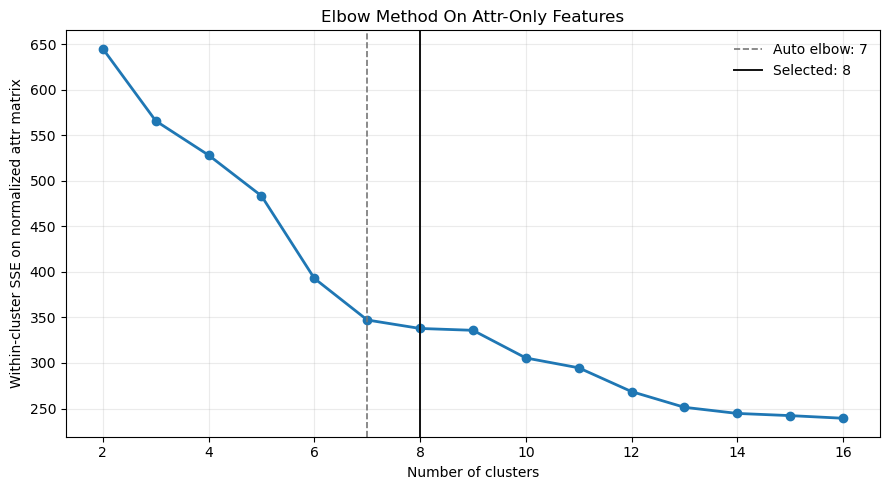

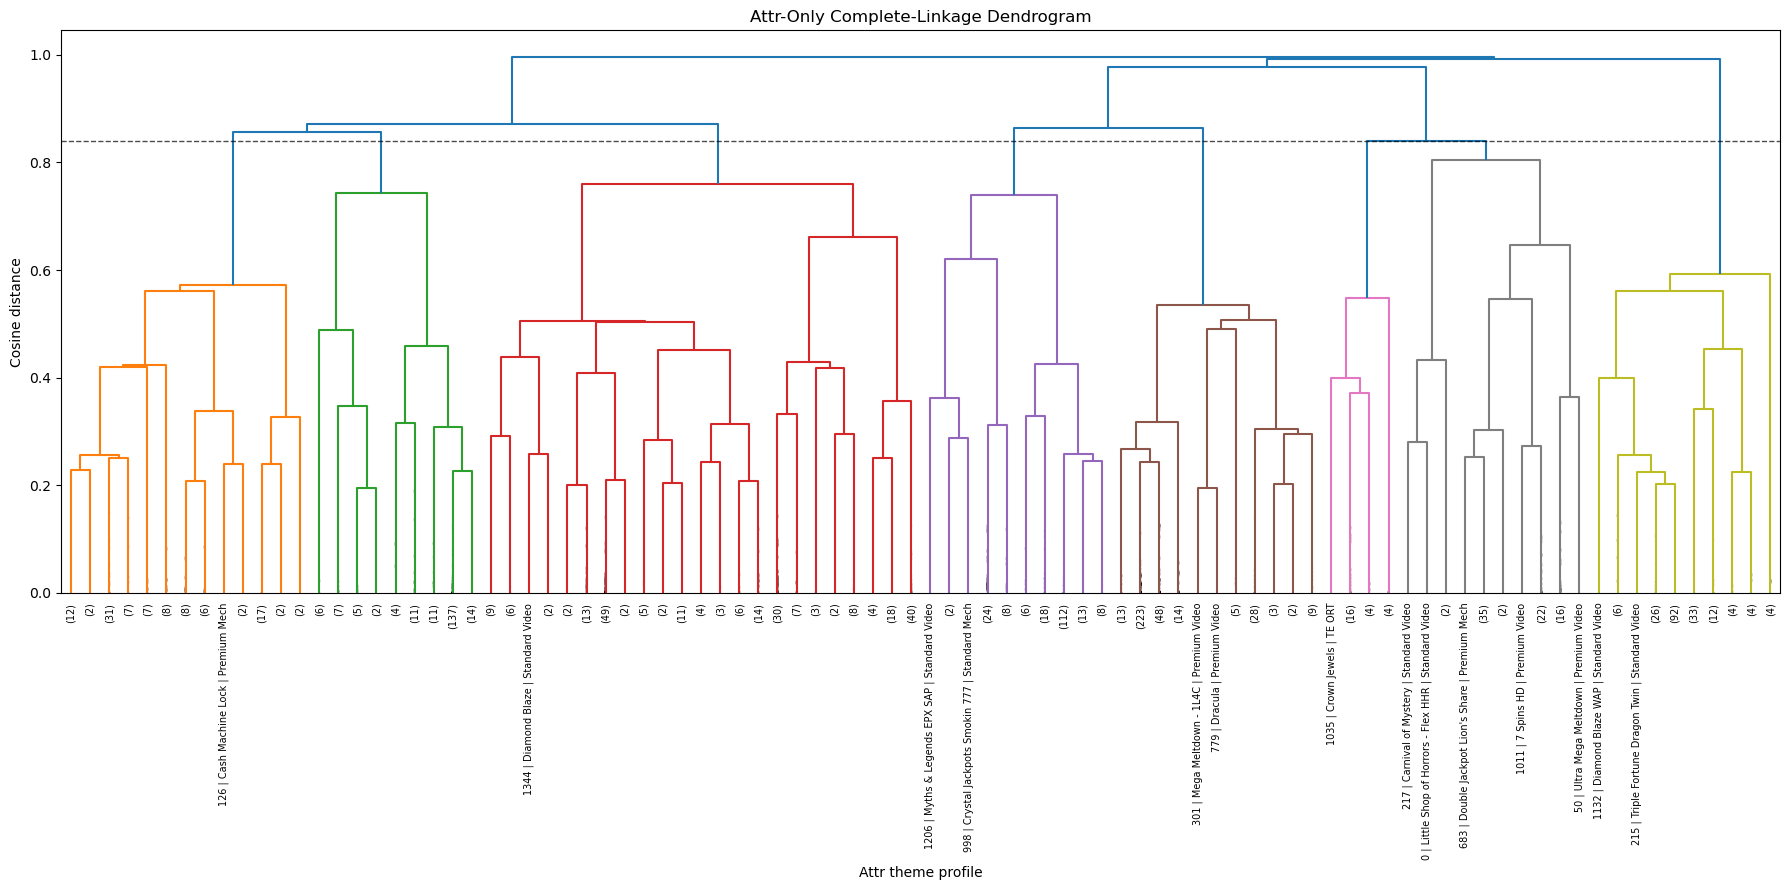

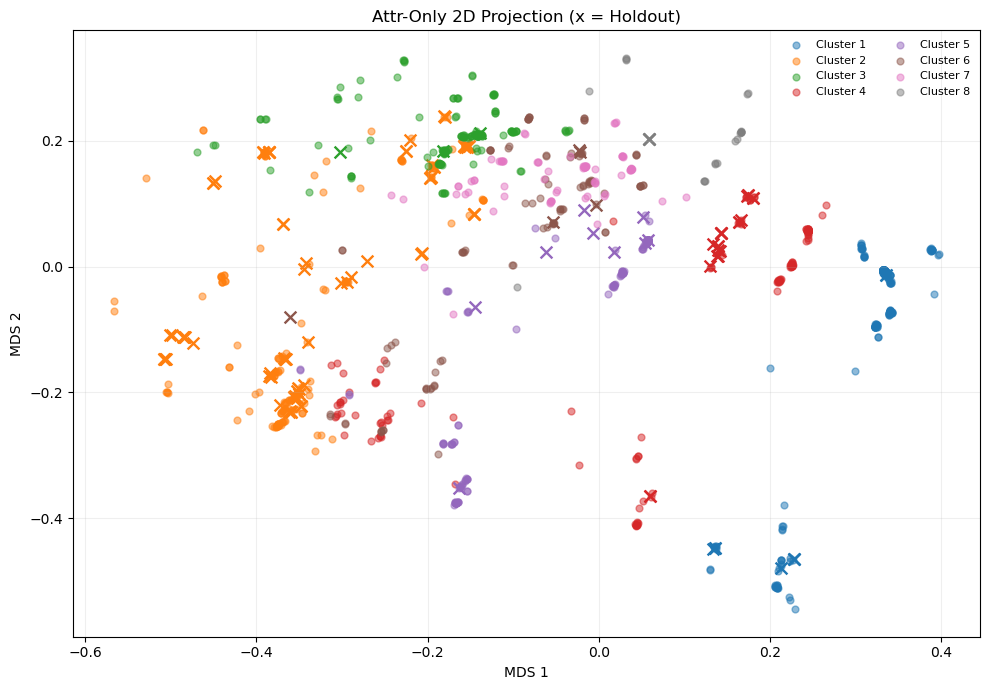

Saved overview visuals:
- c:\EveriTools\Workspace\Code\DemandForeCast\Data\processed\reports\attr_only_elbow_clustering\elbow_method.png
- c:\EveriTools\Workspace\Code\DemandForeCast\Data\processed\reports\attr_only_elbow_clustering\dendrogram_selected_clusters.png
- c:\EveriTools\Workspace\Code\DemandForeCast\Data\processed\reports\attr_only_elbow_clustering\cluster_projection_mds.png


In [12]:
def plot_elbow(elbow_scores):
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(elbow_scores["actual_k"], elbow_scores["within_cluster_sse"], marker="o", linewidth=2)
    auto_k = int(elbow_scores.loc[elbow_scores["elbow_distance_to_line"].idxmax(), "actual_k"])
    selected_k = profiles["cluster_id"].nunique()
    ax.axvline(auto_k, color="#777777", linestyle="--", linewidth=1.2, label=f"Auto elbow: {auto_k}")
    ax.axvline(selected_k, color="#111111", linestyle="-", linewidth=1.4, label=f"Selected: {selected_k}")
    ax.set_title("Elbow Method On Attr-Only Features")
    ax.set_xlabel("Number of clusters")
    ax.set_ylabel("Within-cluster SSE on normalized attr matrix")
    ax.grid(alpha=0.25)
    ax.legend(frameon=False)
    path = OUTPUT_DIR / "elbow_method.png"
    fig.tight_layout()
    fig.savefig(path, dpi=160)
    plt.show()
    return path


def classical_mds(distance_matrix, n_components=2):
    n = distance_matrix.shape[0]
    squared = distance_matrix ** 2
    centering = np.eye(n) - np.ones((n, n)) / n
    gram = -0.5 * centering @ squared @ centering
    eigvals, eigvecs = np.linalg.eigh(gram)
    order = np.argsort(eigvals)[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]
    positive = np.maximum(eigvals[:n_components], 0)
    coords = eigvecs[:, :n_components] * np.sqrt(positive)
    if coords.shape[1] < n_components:
        coords = np.pad(coords, ((0, 0), (0, n_components - coords.shape[1])))
    return coords


def plot_dendrogram_view():
    selected_k = profiles["cluster_id"].nunique()
    cut_distance = linkage_matrix[-(selected_k - 1), 2] if selected_k > 1 else linkage_matrix[-1, 2]
    labels = [
        f"{int(row.profile_id)} | {str(row.theme_name_friendly)[:34]} | {str(row.product_family)[:20]}"
        for row in profiles.itertuples(index=False)
    ]
    fig, ax = plt.subplots(figsize=(18, 9))
    kwargs = {
        "Z": linkage_matrix,
        "labels": labels,
        "leaf_rotation": 90,
        "leaf_font_size": 7,
        "color_threshold": cut_distance,
        "show_contracted": True,
        "ax": ax,
    }
    if len(profiles) > MAX_DENDROGRAM_LEAVES:
        kwargs.update({"truncate_mode": "lastp", "p": MAX_DENDROGRAM_LEAVES})
    dendrogram(**kwargs)
    ax.axhline(cut_distance, color="black", linestyle="--", linewidth=1, alpha=0.7)
    ax.set_title("Attr-Only Complete-Linkage Dendrogram")
    ax.set_xlabel("Attr theme profile")
    ax.set_ylabel(f"{DISTANCE_METRIC.title()} distance")
    path = OUTPUT_DIR / "dendrogram_selected_clusters.png"
    fig.tight_layout()
    fig.savefig(path, dpi=160)
    plt.show()
    return path


def plot_projection():
    coords = classical_mds(distance_matrix)
    profiles["mds_x"] = coords[:, 0]
    profiles["mds_y"] = coords[:, 1]
    fig, ax = plt.subplots(figsize=(10, 7))
    cmap = plt.get_cmap("tab10")
    for idx, cluster_id in enumerate(sorted(profiles["cluster_id"].unique())):
        mask = profiles["cluster_id"].eq(cluster_id)
        historical = mask & ~profiles["is_holdout"]
        holdout = mask & profiles["is_holdout"]
        color = cmap(idx % cmap.N)
        ax.scatter(profiles.loc[historical, "mds_x"], profiles.loc[historical, "mds_y"], s=24, alpha=0.50, color=color, label=f"Cluster {cluster_id}")
        ax.scatter(profiles.loc[holdout, "mds_x"], profiles.loc[holdout, "mds_y"], s=72, marker="x", linewidths=1.7, color=color)
    ax.set_title("Attr-Only 2D Projection (x = Holdout)")
    ax.set_xlabel("MDS 1")
    ax.set_ylabel("MDS 2")
    ax.grid(alpha=0.20)
    ax.legend(ncol=2, fontsize=8, frameon=False)
    path = OUTPUT_DIR / "cluster_projection_mds.png"
    fig.tight_layout()
    fig.savefig(path, dpi=160)
    plt.show()
    return path


elbow_plot_path = plot_elbow(elbow_scores)
dendrogram_path = plot_dendrogram_view()
projection_path = plot_projection()
print("Saved overview visuals:")
for path in [elbow_plot_path, dendrogram_path, projection_path]:
    print(f"- {path}")

In [13]:
def save_cluster_feature_chart(cluster_id):
    lifted = feature_lift.loc[cluster_id].sort_values(ascending=False).head(TOP_CLUSTER_FEATURES)
    labels = [pretty_feature_name(name) for name in lifted.index]
    values = lifted.to_numpy()
    cluster_rows = profiles[profiles["cluster_id"].eq(cluster_id)]
    summary_row = cluster_summary[cluster_summary["cluster_id"].eq(cluster_id)].iloc[0]

    fig, ax = plt.subplots(figsize=(11, 7))
    y = np.arange(len(values))
    ax.barh(y, values, color="#3568a8")
    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel("Feature lift vs global mean")
    ax.set_title(f"Cluster {cluster_id}: Attr Features ({len(cluster_rows)} games, {int(summary_row['holdout_count'])} holdout)")
    ax.grid(axis="x", alpha=0.20)

    text_lines = [
        f"Top product family: {summary_row.get('top_product_family', '')}",
        f"Top product line: {summary_row.get('top_product_line', '')}",
        f"Top game type: {summary_row.get('top_game_type', '')}",
        f"Top matrix: {summary_row.get('top_game_matrix', '')}",
    ]
    fig.text(0.02, 0.02, "\\n".join(text_lines), ha="left", va="bottom", fontsize=9)
    path = CLUSTER_CHART_DIR / f"cluster_{int(cluster_id):02d}_features.png"
    fig.tight_layout(rect=(0, 0.10, 1, 1))
    fig.savefig(path, dpi=160)
    plt.close(fig)
    return path


cluster_chart_paths = []
for cluster_id in sorted(profiles["cluster_id"].unique()):
    cluster_chart_paths.append(save_cluster_feature_chart(cluster_id))

print(f"Saved {len(cluster_chart_paths)} cluster feature charts to {CLUSTER_CHART_DIR}")
display(pd.DataFrame({"cluster_id": sorted(profiles["cluster_id"].unique()), "chart_path": [str(p) for p in cluster_chart_paths]}))

Saved 8 cluster feature charts to c:\EveriTools\Workspace\Code\DemandForeCast\Data\processed\reports\attr_only_elbow_clustering\cluster_feature_charts


,cluster_id,chart_path
0,1,c:\EveriTools\Workspace\Code\DemandForeCast\Da...
1,2,c:\EveriTools\Workspace\Code\DemandForeCast\Da...
2,3,c:\EveriTools\Workspace\Code\DemandForeCast\Da...
3,4,c:\EveriTools\Workspace\Code\DemandForeCast\Da...
4,5,c:\EveriTools\Workspace\Code\DemandForeCast\Da...
5,6,c:\EveriTools\Workspace\Code\DemandForeCast\Da...
6,7,c:\EveriTools\Workspace\Code\DemandForeCast\Da...
7,8,c:\EveriTools\Workspace\Code\DemandForeCast\Da...


In [14]:
def top_active_features(profile_index, n=TOP_HOLDOUT_FEATURES):
    values = feature_matrix.iloc[profile_index].drop(labels=["__profile_bias"], errors="ignore")
    active = values[values > 0].sort_values(ascending=False).head(n)
    return active


def save_holdout_feature_chart(profile_index):
    row = profiles.loc[profile_index]
    active = top_active_features(profile_index)
    target_rows = like_games[like_games["target_profile_id"].eq(row["profile_id"])].sort_values("candidate_rank").head(5)
    like_text = "; ".join(
        f"{item.like_theme_name_friendly} ({item.similarity_score:.3f})"
        for item in target_rows.itertuples(index=False)
    )
    if not like_text:
        like_text = "No like games found"

    fig, (ax_text, ax_bar) = plt.subplots(
        2,
        1,
        figsize=(12, 8),
        gridspec_kw={"height_ratios": [1.1, 2.2]},
    )
    ax_text.axis("off")
    text = (
        f"Holdout: {row.get('theme_name_friendly')}\\n"
        f"Assigned cluster: {int(row.get('cluster_id'))}\\n"
        f"Product family: {row.get('product_family')} | Product line: {row.get('product_line')}\\n"
        f"Game type: {row.get('game_type')} | Game matrix: {row.get('game_matrix')}\\n"
        f"Release date: {row.get('profile_release_date')} | Historical mapping: {row.get('best_historical_game_name')}\\n"
        f"Top like games: {like_text}"
    )
    ax_text.text(0.01, 0.98, text, va="top", ha="left", fontsize=10, wrap=True)

    labels = [pretty_feature_name(name) for name in active.index]
    values = active.to_numpy()
    y = np.arange(len(values))
    ax_bar.barh(y, values, color="#2f7f63")
    ax_bar.set_yticks(y)
    ax_bar.set_yticklabels(labels, fontsize=9)
    ax_bar.invert_yaxis()
    ax_bar.set_xlabel("Weighted active attr feature value")
    ax_bar.set_title("Strongest Active Attr Features For This Holdout")
    ax_bar.grid(axis="x", alpha=0.20)

    file_name = f"holdout_{int(row['profile_id']):04d}_cluster_{int(row['cluster_id']):02d}_{safe_filename(row.get('theme_name_friendly'))}.png"
    path = HOLDOUT_CHART_DIR / file_name
    fig.tight_layout()
    fig.savefig(path, dpi=160)
    plt.close(fig)
    return path


holdout_chart_rows = []
for profile_index in profiles.index[profiles["is_holdout"]]:
    path = save_holdout_feature_chart(profile_index)
    row = profiles.loc[profile_index]
    holdout_chart_rows.append({
        "profile_id": int(row["profile_id"]),
        "theme_name_friendly": row.get("theme_name_friendly"),
        "cluster_id": int(row.get("cluster_id")),
        "chart_path": str(path),
    })

holdout_chart_index = pd.DataFrame(holdout_chart_rows).sort_values(["cluster_id", "theme_name_friendly"])
print(f"Saved {len(holdout_chart_index)} holdout feature charts to {HOLDOUT_CHART_DIR}")
display(holdout_chart_index.head(20))

Saved 138 holdout feature charts to c:\EveriTools\Workspace\Code\DemandForeCast\Data\processed\reports\attr_only_elbow_clustering\holdout_feature_charts


,profile_id,theme_name_friendly,cluster_id,chart_path
124,280,Ice On Fire,1,c:\EveriTools\Workspace\Code\DemandForeCast\Da...
128,359,Ice On Fire,1,c:\EveriTools\Workspace\Code\DemandForeCast\Da...
129,390,Ice On Fire,1,c:\EveriTools\Workspace\Code\DemandForeCast\Da...
126,324,Jackpot Express,1,c:\EveriTools\Workspace\Code\DemandForeCast\Da...
122,229,Jackpot Express - 5L5C,1,c:\EveriTools\Workspace\Code\DemandForeCast\Da...
125,323,Jackpot Express - 5L5C,1,c:\EveriTools\Workspace\Code\DemandForeCast\Da...
132,680,Smokin Hot Diamonds,1,c:\EveriTools\Workspace\Code\DemandForeCast\Da...
133,681,Smokin Hot Diamonds,1,c:\EveriTools\Workspace\Code\DemandForeCast\Da...
123,251,Triple Jackpot Smokin 777 - 5L,1,c:\EveriTools\Workspace\Code\DemandForeCast\Da...
24,69,888 Drums Eternity,2,c:\EveriTools\Workspace\Code\DemandForeCast\Da...


In [ ]:
profiles.to_csv(PROFILES_OUTPUT_PATH, index=False)
feature_matrix.to_csv(FEATURE_MATRIX_OUTPUT_PATH, index=False)
like_games.to_csv(MAPPING_OUTPUT_PATH, index=False)
grouped_like_games.to_csv(GROUPED_MAPPING_OUTPUT_PATH, index=False)
cluster_summary.to_csv(CLUSTER_SUMMARY_OUTPUT_PATH, index=False)
elbow_scores.to_csv(ELBOW_OUTPUT_PATH, index=False)
holdout_chart_index.to_csv(CHART_INDEX_OUTPUT_PATH, index=False)

manifest = {
    "inputs": {
        "attr_path": str(ATTR_PATH),
        "attr_raw_path": str(ATTR_RAW_PATH),
        "rel_map_path": str(REL_MAP_PATH),
    },
    "profile_rows": int(len(profiles)),
    "feature_columns": int(feature_matrix.shape[1]),
    "feature_source_counts": {str(k): int(v) for k, v in pd.Series(feature_sources).value_counts().items()},
    "holdout_profiles": int(profiles["is_holdout"].sum()),
    "historical_profiles": int(profiles["is_qualified_historical"].sum()),
    "mapped_holdout_profiles": int(like_games["target_profile_id"].nunique()),
    "mapping_rows": int(len(like_games)),
    "auto_elbow_k": int(auto_elbow_k),
    "selected_clusters": int(profiles["cluster_id"].nunique()),
    "selected_clusters_setting": int(ELBOW_SELECTED_N_CLUSTERS),
    "excluded_match_methods": sorted(EXCLUDED_MATCH_METHODS),
    "distance_metric": DISTANCE_METRIC,
    "linkage_method": LINKAGE_METHOD,
    "excluded_feature_families": ["cabinet_name", "performance"],
    "outputs": {
        "profiles": str(PROFILES_OUTPUT_PATH),
        "feature_matrix": str(FEATURE_MATRIX_OUTPUT_PATH),
        "mapping": str(MAPPING_OUTPUT_PATH),
        "grouped_mapping": str(GROUPED_MAPPING_OUTPUT_PATH),
        "cluster_summary": str(CLUSTER_SUMMARY_OUTPUT_PATH),
        "elbow_scores": str(ELBOW_OUTPUT_PATH),
        "chart_index": str(CHART_INDEX_OUTPUT_PATH),
        "cluster_chart_dir": str(CLUSTER_CHART_DIR),
        "holdout_chart_dir": str(HOLDOUT_CHART_DIR),
        "report_dir": str(OUTPUT_DIR),
    },
}
MANIFEST_OUTPUT_PATH.write_text(json.dumps(manifest, indent=2, default=str), encoding="utf-8")

print("Saved outputs:")
for path in [
    PROFILES_OUTPUT_PATH,
    FEATURE_MATRIX_OUTPUT_PATH,
    MAPPING_OUTPUT_PATH,
    GROUPED_MAPPING_OUTPUT_PATH,
    CLUSTER_SUMMARY_OUTPUT_PATH,
    ELBOW_OUTPUT_PATH,
    CHART_INDEX_OUTPUT_PATH,
    MANIFEST_OUTPUT_PATH,
]:
    print(f"- {path}")

Saved outputs:
- c:\EveriTools\Workspace\Code\DemandForeCast\Data\processed\attr_only_elbow_profiles.csv
- c:\EveriTools\Workspace\Code\DemandForeCast\Data\processed\attr_only_elbow_features.csv
- c:\EveriTools\Workspace\Code\DemandForeCast\Data\processed\attr_only_elbow_like_game_mapping.csv
- c:\EveriTools\Workspace\Code\DemandForeCast\Data\processed\attr_only_elbow_like_game_mapping_grouped.csv
- c:\EveriTools\Workspace\Code\DemandForeCast\Data\processed\attr_only_elbow_cluster_summary.csv
- c:\EveriTools\Workspace\Code\DemandForeCast\Data\processed\reports\attr_only_elbow_clustering\elbow_scores.csv
- c:\EveriTools\Workspace\Code\DemandForeCast\Data\processed\reports\attr_only_elbow_clustering\chart_index.csv
- c:\EveriTools\Workspace\Code\DemandForeCast\Data\processed\reports\attr_only_elbow_clustering\manifest.json


: 